<img style="float: left;" src="Lecture_thermo/Slide2.PNG" width="100%">

<img style="float: left;" src="Lecture_thermo/Slide3.PNG" width="100%">

<img style="float: left;" src="Lecture_thermo/Slide6.PNG" width="100%">

<img style="float: left;" src="Lecture_thermo/Slide7.PNG" width="100%">

## <span style="color:red">Exercise 1:  Compressibility graph</span>

#### Plot graph of compressibility Z vs. normal pressure for:
 * Pure methane
 * Mixture of methane (85%), nitrogen (10%) and carbon dioxide (5%)
#### at 3 temperatures T = 30, 60 and 90 C

In [2]:
# procedure returning critical properties for several components
def props(component, params):
    properties = [["C1",    "CO2",   "N2",    "H2S",   "C2",    "H2"],      # component
                  [190.58,  304.10,  126.20,  373.53,  305.32,  33.0],      # T_c [K]
                  [46.04,   73.75,   34.00,   89.63,   48.72,   13.0],      # p_c [bar]
                  [16.043,  44.01,   28.013,  34.076,  30.07,   2.02]]      # molecular mass [g/mol]
                                                             
    name = ["Tc", "Pc", "Mw"]
    index1 = name.index(params) + 1
    index2 = properties[0][:].index(component)
    c = properties[index1][index2]

    return c

# procedure returning binary  for several components
def binary(component, components):
    # binary interaction parameters for CH4, CO2 ...    
    # binary interaction parameters for CH4, CO2 ...    
    dij = [["CO2",    "C1",      "N2",   "H2S",   "C2",  "H2"],  
           [ 0,       0.100,  -0.017,   0.0974,   0.1,   0.1 ],
           [ 0.100,   0,       0.0311,  0.0503,   0,    -0.1 ],
           [-0.017,   0.0311,  0,       0.1767,   0.1,   0.14],
           [ 0.0974,  0.0503,  0.1767,  0,        0.05,  0.02],
           [ 0.1,     0,       0.1,     0.05,     0,     0.01],
           [ 0.1,    -0.1,     0.14,    0.02,     0.0,   0   ]]  

    d = []
    index1 = dij[0].index(component) + 1
    for c in components:
        index2 = dij[0].index(c)
        d.append(dij[index1][index2])
        
    return d


# compute Z based on van der Waals EoS
def vapour_compress(p, T, x, components):
    NC = np.size(x)
    R = 8.3145E-5

    b = 0
    ai = np.zeros(NC)
    for i in range(NC):
        Tc = props(components[i], "Tc")
        Pc = props(components[i], "Pc")
        ai[i] = (0.4219 * R ** 2 * Tc ** 2) / Pc
        b += x[i] * (0.125 * R * Tc) / Pc

    a = 0
    for i in range(NC):
        d = binary(components[i], components)
        for j in range(NC):            
            aij = (1 - d[j]) * (ai[i] ** 0.5) * (ai[j] ** 0.5)
            a +=  x[i] * x[j] * aij

    A = - ((R * T / p) + b)
    B = a / p
    C = - (a * b) / p

    # solve cubic equations with corresponding coefficient 
    V = np.roots([1, A, B, C])  # 3 real roots: take max
    
    if np.sum(np.isreal(V)) == 3:
        V_out = np.amax(V)          # Z is max root out of 3
    else:
        index = np.isreal(V)
        V_out = np.real(V[index])   # Z is the only real root
        
    Z_out = (p * V_out) / (R * T)

    return Z_out

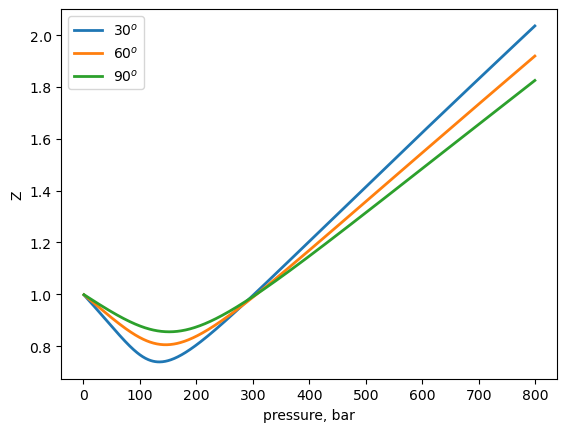

In [5]:
import numpy as np
import matplotlib.pyplot as plt

t_list = [303.15, 333.15, 363.15] # temperature in Kelvins

comp = ["C1", "N2", "CO2"] # component names
y = [0.95, 0.10, 0.05] # molar fractions of components

for t in t_list:
    zz = []
    pp = []

    for p in range(1, 800):
        z = vapour_compress(p, t, y, comp)
        pp.append(p)
        zz.append(z)

    plt.plot(pp, zz, linewidth=2)

plt.legend(['$30^o$', '$60^o$', '$90^o$'])
plt.xlabel('pressure, bar')
plt.ylabel('Z')
plt.show()